# M2.Ex1: Advertising Revenue

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M2/exercises/ex1_multi-reg.ipynb)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split



## Advertising Dataset

The Advertising Dataset is a fundamental resource in statistical learning and regression analysis. It is primarily known for its use in the first chapter of the seminal textbook "An Introduction to Statistical Learning" (ISLR) by Gareth James, Daniela Witten, Trevor Hastie, and Robert Tibshirani.

The dataset is used to illustrate the relationship between advertising budgets across different media and the resulting product sales.

- Features: `3` numerical
- Target: `sales` of the product (in thousands of units).
- Size: `200` samples.
- Source: [Advertising Dataset](https://www.statlearning.com/s/Advertising.csv)

### Step 1. Load the data

In [2]:
# Step 1. Load the data
df = pd.read_csv("advertising.csv")   # أو اسم الملف الموجود في التمرين
df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


### Step 2.a Assign variables `X` to the features and `y` to the target

In [3]:
# Step 2 assign X and y (آخر عمود هو target)
X = df.iloc[:, :-1]
y = df.iloc[:, -1]


### Step 2.b print the type of each

In [4]:
# Step 2.b print the type of each
print("Type of X:", type(X))
print("Type of y:", type(y))



Type of X: <class 'pandas.DataFrame'>
Type of y: <class 'pandas.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [5]:
# Step 2.c identify whether the target is categorical or numerical
# & whether the task is regression or classification
print("\nTarget is numerical.")
print("Task is Regression.")




Target is numerical.
Task is Regression.


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [6]:
# Step 3 Identify number of samples and columns
print("\nX shape:", X.shape)
print("y shape:", y.shape)
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])




X shape: (200, 4)
y shape: (200,)
Number of samples: 200
Number of features: 4


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [7]:
# Step 4 Summarize distribution
summary = X.agg(["min","max","median","mean","std"])
print("\nSummary statistics:")
print(summary)



Summary statistics:
        Unnamed: 0          TV      radio   newspaper
min       1.000000    0.700000   0.000000    0.300000
max     200.000000  296.400000  49.600000  114.000000
median  100.500000  149.750000  22.900000   25.750000
mean    100.500000  147.042500  23.264000   30.554000
std      57.879185   85.854236  14.846809   21.778621


### Step 5. How much difference do you see in the scale of each feature? (calculate the featre-wise range differences)

In [14]:
range_diff = X.max() - X.min()

print("Feature-wise range differences:")
print(range_diff)

Feature-wise range differences:
Unnamed: 0    199.0
TV            295.7
radio          49.6
newspaper     113.7
dtype: float64


### Step 6.a Plot each of the features vs the target

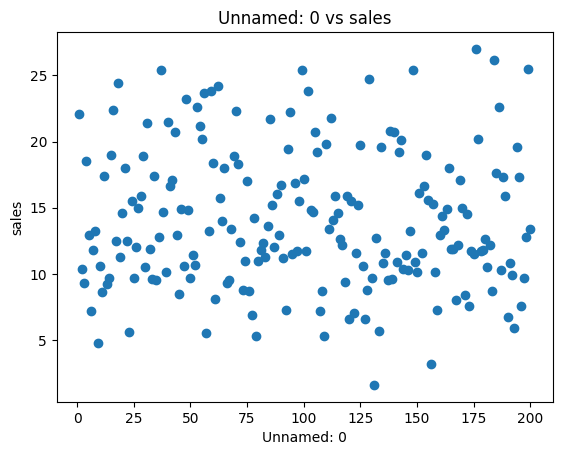

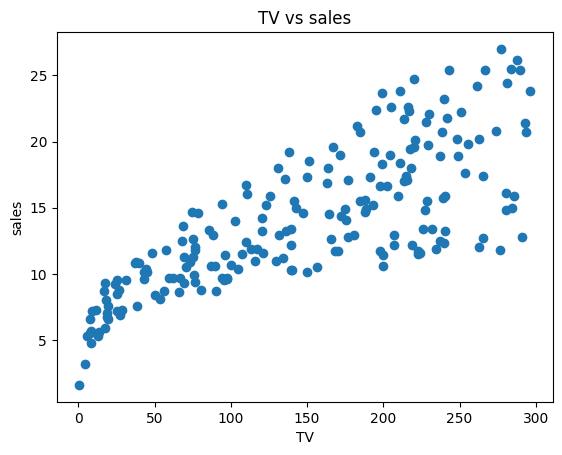

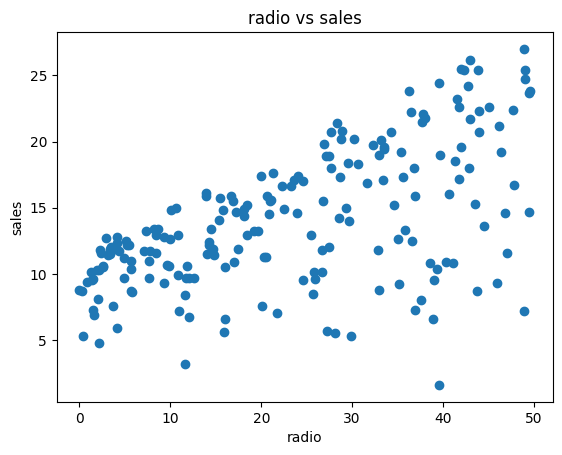

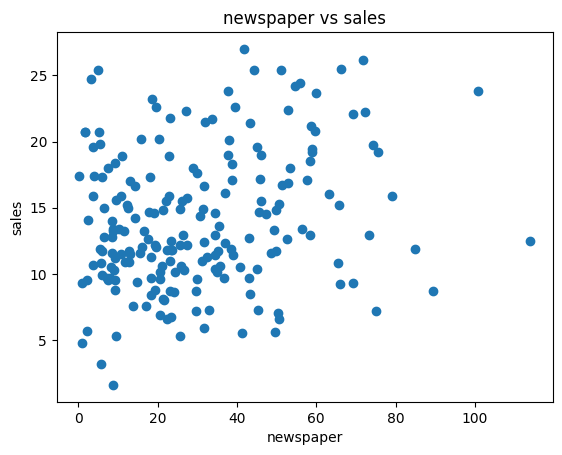

In [13]:
for col in X.columns:
    
    plt.figure()
    
    plt.scatter(X[col], y)
    
    plt.xlabel(col)
    plt.ylabel(y.name)
    
    plt.title(f"{col} vs {y.name}")
    
    plt.show()

### Step 6.b What is the relationship between the feature and the target? (increasing or decreasing or none)

1. `x=TV` and `y=Sales`
2. `x=Radio` and `y=Sales`
3. `x=Newspaper` and `y=Sales`

1. **x = TV** and **y = Sales**  
   → Increasing relationship   
   As TV advertising increases, Sales tend to increase.

2. **x = Radio** and **y = Sales**  
   → Increasing relationship  
   As Radio advertising increases, Sales also increase.

3. **x = Newspaper** and **y = Sales**  
   → Weak increasing or no clear relationship  
   The effect of Newspaper advertising on Sales is less clear compared to TV and Radio.

### Step 7. Define the pipeline with pre-processing steps

Make a Pipeline of three sequential steps:

1. transformer: `SimpleImputer` (to fill in missing values)
2. transformer: `StandardScaler` (to scale numerical features)
3. predictor: `LinearRegression` (to model the relationship)

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

pipeline = Pipeline([
    ("imputer", SimpleImputer()),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])
# Step 7 Initialize model
model = LinearRegression()



### Step 8. Split the dataset into train and test sets

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### Step 9.a Fit the pipeline on the training set

In [17]:
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Step 9.b Identify the learned coefficients (for each feature) and the bias term

In [18]:
print(model.score(X_test, y_test))

0.8986489151417079


### Step 9.c how much spending on TV `$1,000` more, factor into Sales?

In [20]:
tv_coef = model.coef_[0]

increase_sales = tv_coef * 1

print("Increase in Sales when TV spending increases by $1,000:")
print(increase_sales)

Increase in Sales when TV spending increases by $1,000:
0.0006435900404989981


### Step 9.d if we take `$5,000` away from Newspaper and put it in Radio how much difference does that make into Sales?

In [21]:
radio_coef = model.coef_[1]
news_coef = model.coef_[2]

change_sales = (radio_coef * 5) - (news_coef * 5)

print("Change in Sales:", change_sales)

Change in Sales: -0.7226641637736702


### Step 9.e if we spend nothing at all on advertising, how much do we estimate our Sales to be?

If we spend nothing on advertising, the estimated Sales equals the intercept value.

Because when all features = 0, the prediction equals the intercept.

### Step 10. Evaluate the pipeline on the test set

In [22]:
score = model.score(X_test, y_test)

print("Pipeline R² score:", score)

Pipeline R² score: 0.8986489151417079


### Step 11. Define a `LinearRegression` model without the pre-processing steps, and compare it's score with the pipeline. Which one is better?

In [23]:
from sklearn.linear_model import LinearRegression

model_simple = LinearRegression()

model_simple.fit(X_train, y_train)

simple_score = model_simple.score(X_test, y_test)

print("Pipeline score:", score)
print("Simple LinearRegression score:", simple_score)

if score > simple_score:
    print("Pipeline performs better.")
else:
    print("Simple LinearRegression performs better or similar.")

Pipeline score: 0.8986489151417079
Simple LinearRegression score: 0.8986489151417079
Simple LinearRegression performs better or similar.
